FS0432

Segundo Parcial ii -25

# Primera Parte: Respuestas Concretas (40%)

1. Describa brevemente el algoritmo QR. ¿Para qué funciona? Mencione una desventaja.

**Respuesta**

- El QR consiste en descomponer una matriz $A$ en un producto de dos matrices $Q$ y $R$ tales que $Q$ es una matriz cuyas columnas conforman una base ortonormal y $R$ es una matriz triangular superior.
- Funciona para encontrar los valores propios y los vectores propios d  $A$.
- No funciona si la matriz no es **simétrica real** o **Hermítica**.

2. Describa tres situaciones principales en las cuales se requiere el uso de HPC en computación científica.

**Respuesta**

- El problema toma mucho tiempo -> se requiere más recursos (más unidades).
- El problema es muy grande -> se requiere gran cantidad de memoria.
- Los datos generados son muy grandes -> se requiere grandes cantidades de almacenamiento para depuración.

3. Cuando aplicamos métodos de espaciamiento temporal (e.g., Euler, RK2, RK4) la solución puede dar lugar a violaciones de la conservación de la energía para sistemas aislados. ¿A qué se debe esta discrepancia y cómo se puede resolver?

**Respuesta**

- No sabemos el por qué. Creemos que es porque no respetan la simetría temporal, pero si es así, no sabemos cuál es la relación de uno con lo otro.
- Se puede solucionar con el método de **leapfrog**. En el leapfrog, a diferencia de, por ejemplo, RK2, cada punto medio se calcula calcula con base en el punto medio anterior.

4. El algoritmo tradicional para evaluar una transformada de Fourier discreta de $N$ términos requiere $\mathcal{O}(N^2)$ operaciones. Describa brevemente en qué consiste el algoritmo sobre el cual se puede evaluar la transformada de Fourier dsicreta de $N$ términos utilizando $\mathcal{O} (N\  \text{log}_2 N)$ operaciones.

En "dividir y conquistar"

https://github.com/CocoUrbina/FisicaComputacional/blob/master/12.Fourier/DFT.ipynb

5. 
```C++
#include <iostream>
#include <omp.h>

int main(){

    int i = 1;
    #pragma omp parallel
    {
        int j = 0;
        int k = 2;
    }

    return 0;
}
```

¿Cuáles de las variables del código anterior son compartidas y cuáles son privadas?

**Respuesta**

i: compartida

j, k: privadas

6. Queremos resolver el problema **Ax** = **f**; donde **A** es una matriz y **x** , **f** son vectores, usando la descomposición **A** = **LU**. ¿Cuál o cuales sistemas debo resolver con base en esta descomposición para encontrar **x**? ¿Cuál es la limitación más importante de la descomposición matricial **A** = **LU**?

Check this out: https://github.com/CocoUrbina/FisicaComputacional/blob/master/15.LinearSys/SistemasLineales.ipynb

7. Realice un gráfico de la parte imaginaria de la transformada de Fourier de $f(x) = \frac{1}{2} \sin(2 \pi x) + 2 \sin (4 \pi x)$.

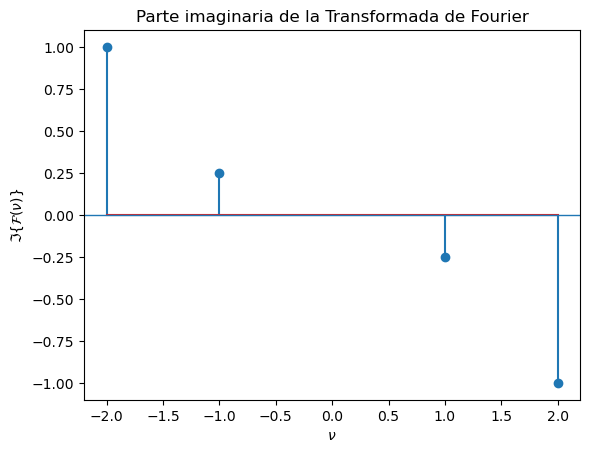

8. Describa brevemente los componentes del método Crank-Nicholson y la razón por la cuál se requiere dicho método.

Check this out: https://github.com/CocoUrbina/FisicaComputacional/blob/master/14.PDE/PDE3_hiperbolicas.ipynb 

# Segunda Parte: Desarrollo (60%)

1. (20%) Derive la ecuación (regla de actualización) del método de relajación de Jacobi para la ecuación de Gauss en dos dimensiones
   
$$\frac{\partial ^2 \phi (x,y)}{\partial x^2} + \frac{\partial ^2 \phi (x,y)}{\partial y^2} = -\frac{\rho (x, y)}{\epsilon_0}  \tag{2.1}$$

donde $\rho(x,y)$ es una densidad de cargas y $\epsilon_0$ una constante. Asuma un espaciamiento de la grilla (_lattice spacing_) de valor $a$. 

**Solución**

De diferencias centrales,
    \begin{equation}
    \frac{d^2f(x)}{dx^2} \approx \frac{f(x+a) - 2f(x) + f(x-a)}{a^2},
    \end{equation}
    Donde $a$ es el parámetro de control de la aproximación.

Extendiendo este resultado a derivadas parciales,
    
\begin{equation}
    \frac{\partial ^2 \phi(x,y)}{\partial x^2} \approx \frac{\phi(x+a,y) - 2\phi(x,y) + \phi(x-a,y)}{a^2} \tag{2.1.1},
\end{equation}

\begin{equation}
    \frac{\partial ^2 \phi(x,y)}{\partial y^2} \approx \frac{\phi(x,y+a) - 2\phi(x,y) + \phi(x,y-a)}{a^2} \tag{2.1.2},
\end{equation}

(2.1.1) y (2.1.2) en (2.1),

\begin{equation}
    \frac{\phi(x+a,y) - 2\phi(x,y) + \phi(x-a,y)}{a^2} + \frac{\phi(x,y+a) - 2\phi(x,y) + \phi(x,y-a)}{a^2} = -\frac{\rho(x,y)}{ \epsilon_0}
\end{equation}

\begin{equation}
    \phi(x+a,y) + \phi(x-a,y) + \phi(x,y+a) + \phi(x,y-a) - 4\phi(x,y) = - \frac{a^2}{ \epsilon_0} \rho(x,y)
\end{equation}

\begin{equation}
    \boxed{\frac{1}{4} \left[\phi(x+a,y) + \phi(x-a,y) + \phi(x,y+a) + \phi(x,y-a)\right] + \frac{a^2}{ 4 \epsilon_0} \rho(x,y) = \phi^\prime(x,y)}
\end{equation}

2. (20%) La Transformada de Fourier Discreta (DFT) equivale a evaluar los $N$ coeficientes de Fourier:

$$c_k = \sum_{n=0} ^ {N-1} y_n \exp{\left( -i \frac{2\pi kn}{N} \right)} \tag{2.2}$$

donde $y_n \equiv f(x_k)$, $f$ la función de la cual queremos la transformada de Fourier y $x_k$ los puntos de colocación (discretización) de la variable independiente en el espacio. Asuma que usted quiere escribir una función que devuelve la transformada de Fourier en un `numpy.ndarray` de forma _ingenua_, i.e., usando la ecuación anterior. Escriba una función en `Python` que realiza dicha operación. La firma de la función es:

```Python
def dft(input):
    # Su codigo aqui
    return output
```

donde `input` es un arreglo que contiene el vector de entrada (los $y_n$) y la función devuelve un arreglo `output` del mismo tamaño con los valores de $c_k$.

**Solución**

```Python
def dft(input):
    
    N = input.size                                # tamaño de N
    input = np.asarray(input, dtype=complex)      # se pasa el input a un complex
    output = np.zeros(N, dtype=complex)           # se crea output, de tamano n, complex
    
    for k in range(N):                            # recorre el k
        for n in range(N):                        # recorre el n
            output[k] += input[n] * np.exp(-j * 2 * np.pi * k * n / N)   # computa el c_k

    return output                                 # retorna la coleccion de los c_k
```

3. (20%) Describa _matemáticamente_ el procedimiento numérico (las operaciones que debe realizar), para resolver

$$\frac{d^2 x}{dt^2} = f\left( x, \frac{dx}{dt}, t  \right) \tag{2.3}$$

bajo las condiciones $x(t=0) = x_0$ y $\displaystyle \left[ \frac{dx}{dt} \right]_{t=0} = y_0$ utilizando el método de Euler.

**Solución**

- Se reduce el orden la ODE como sigue:
  
 $\displaystyle \frac{dx}{dt} := y$

 $\displaystyle \frac{dy}{dt} = f(x,y,t)$

 - Se resuelven las ODEs con Euler:

$\begin{cases}
x(t+h) = x(t) + h y(t)\\
y(t+h) = y(t) +h f(x,y,t)
\end{cases}$

O bien,

$\displaystyle
\begin{pmatrix}
x \\ y
\end{pmatrix}_{n+1} =
\begin{pmatrix}
1 & h \\
0 & 1
\end{pmatrix}
\begin{pmatrix}
x \\ y
\end{pmatrix}_n +
h\begin{pmatrix}
0 \\
f(x,y,t)
\end{pmatrix}_n
$

- Se resuelve con Euler:
1. Inicialiar: $t_0 = 0$, $x(t=0) = x_0$, $y(t=0) = y_0$.
2. Calcular $a_n = f(x_n, y_n , t_n)$
3. Actualizar $x$: $x_{n+1} = x_n + hy_n$
4. Actualzar $y$: $y_{n+1} = y_n+ ha_n$
5. Actualizar $t$ (siguiente paso): $t_{n+1} = t_n + h$